In [1]:
%matplotlib ipympl

# FFT

## Generate Test Signal (Iput and Output) For FFT Test

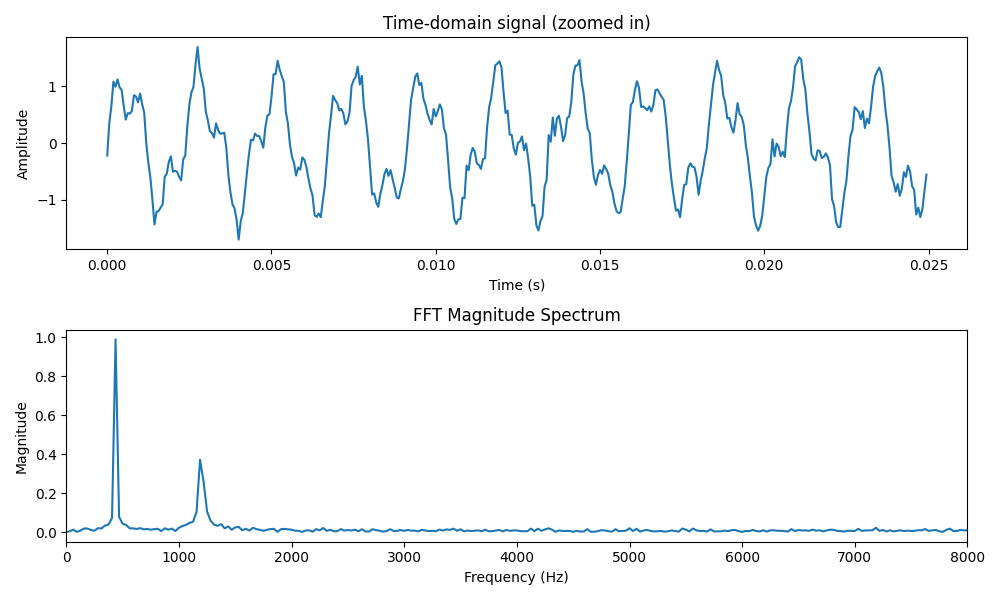

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def gen_sig_and_plot(num_samples=4096, fs=16000):
    # --- 1. Generate a test signal ---
    t = np.arange(num_samples) / fs   # sample times, based on fixed sample count

    f1, f2 = 440, 1200   # frequencies of two tones (Hz)
    signal = (
        1.0 * np.sin(2 * np.pi * f1 * t) +
        0.5 * np.sin(2 * np.pi * f2 * t) +
        0.1 * np.random.randn(num_samples)    # a bit of noise
    )

    # --- 2. Perform the FFT ---
    N = len(signal)
    fft_vals = np.fft.rfft(signal)          # real-input FFT (only positive freqs)
    fft_freqs = np.fft.rfftfreq(N, d=1/fs)  # corresponding frequency bins
    fft_mag = np.abs(fft_vals) / N * 2      # normalized magnitude

    # --- 3. Plot time-domain and frequency-domain views ---
    fig, axes = plt.subplots(2, 1, figsize=(10, 6))

    zoom = min(400, num_samples)
    axes[0].plot(t[:zoom], signal[:zoom])   # zoom into first N samples (or fewer if signal is shorter)
    axes[0].set_title("Time-domain signal (zoomed in)")
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Amplitude")

    axes[1].plot(fft_freqs, fft_mag)
    axes[1].set_title("FFT Magnitude Spectrum")
    axes[1].set_xlabel("Frequency (Hz)")
    axes[1].set_ylabel("Magnitude")
    axes[1].set_xlim(0, fs / 2)

    plt.tight_layout()
    plt.show()
    return signal, fft_vals

signal, fft_vals = gen_sig_and_plot(num_samples=512, fs=16000)

In [3]:
import numpy as np
from pathlib import Path

# --- Helper: format a float32 array as C source body ---
def format_array_body(data, per_line=8):
    lines = []
    for i in range(0, len(data), per_line):
        row = ", ".join(f"{v:.10f}f" for v in data[i:i+per_line])
        lines.append("    " + row + ",")
    return "\n".join(lines)

# --- Helper: write a single array as a .c/.h pair into a target directory ---
def write_c_pair(name, data, output_dir=".", dtype="float32_t"):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    c_path = output_dir / f"{name}.c"
    h_path = output_dir / f"{name}.h"
    guard = f"{name.upper()}_H"

    body = format_array_body(data)

    with open(c_path, "w") as f:
        f.write(f'#include "{h_path.name}"\n\n')
        f.write(f"const uint32_t {name.upper()}_LEN = {len(data)};\n\n")
        f.write(f"{dtype} {name}[{len(data)}] = {{\n{body}\n}};\n")

    with open(h_path, "w") as f:
        f.write(f"#ifndef {guard}\n#define {guard}\n\n")
        f.write(f'#include "arm_math.h"\n\n')
        f.write(f"extern const uint32_t {name.upper()}_LEN;\n")
        f.write(f"extern {dtype} {name}[{len(data)}];\n\n")
        f.write(f"#endif // {guard}\n")

    print(f"Wrote {c_path} and {h_path}")

# --- Repack a numpy rfft result into CMSIS arm_rfft_fast_f32 packed format ---
def pack_cmsis_rfft(fft_ref, N):
    if len(fft_ref) != N // 2 + 1:
        raise ValueError(f"fft_ref length {len(fft_ref)} does not match expected N/2+1 = {N//2+1}")

    packed = np.zeros(N, dtype=np.float32)
    packed[0] = fft_ref[0].real          # DC
    packed[1] = fft_ref[N // 2].real     # Nyquist (packed into DC's imag slot)
    for k in range(1, N // 2):
        packed[2 * k] = fft_ref[k].real
        packed[2 * k + 1] = fft_ref[k].imag
    return packed

# --- Top-level reusable export function ---
def export_rfft_test_vectors(name_prefix, signal, fft_ref, N, output_dir="."):
    """
    Writes two .c/.h pairs for use as CMSIS arm_rfft_fast_f32 unit test vectors:
      {name_prefix}_input.c/.h      - the time-domain input signal
      {name_prefix}_fft_output.c/.h - the expected CMSIS-packed FFT output

    Parameters
    ----------
    name_prefix : str
        Base name used for generated files and C symbol names.
    signal : array-like, float32
        Time-domain input signal, length N.
    fft_ref : array-like, complex
        Output of np.fft.rfft(signal), length N/2 + 1.
    N : int
        FFT length (must be a CMSIS-supported size: 32...4096, power of 2).
    output_dir : str or Path
        Directory to write the .c/.h files into. Created if it doesn't exist.
    """
    signal = np.asarray(signal, dtype=np.float32)
    if len(signal) != N:
        raise ValueError(f"signal length {len(signal)} does not match N = {N}")

    packed = pack_cmsis_rfft(fft_ref, N)

    write_c_pair(f"{name_prefix}_input", signal, output_dir=output_dir)
    write_c_pair(f"{name_prefix}_fft_output", packed, output_dir=output_dir)


# --- Usage ---
N = len(signal)
export_rfft_test_vectors("test_signal", signal, fft_vals, N, output_dir="./test_vectors")

Wrote test_vectors/test_signal_input.c and test_vectors/test_signal_input.h
Wrote test_vectors/test_signal_fft_output.c and test_vectors/test_signal_fft_output.h


## Graph C Output

Parsed 516 values


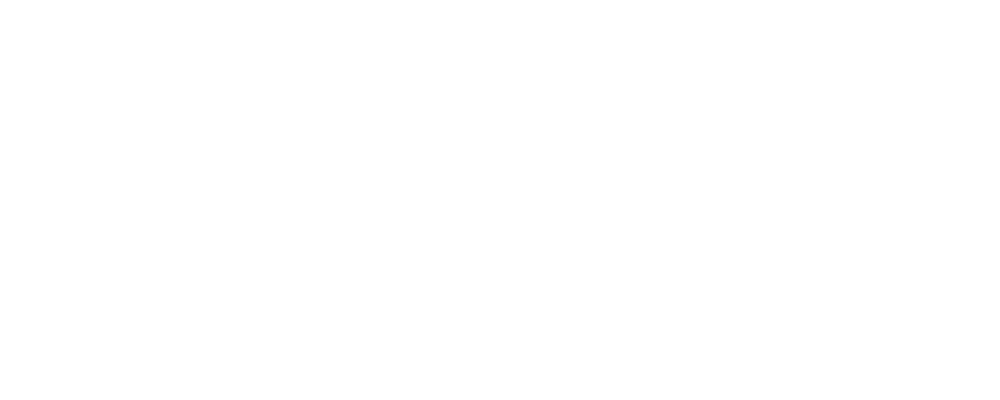

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import re

# --- 1. Paste your raw C output here as a single string ---
raw_output = """
  - "-0.5450776 3.253913 3.9236 -1.365729 2.677833 0.8881148"
  - "2.134512 -0.44824 -1.542978 0.9826043 4.0324 -2.171612"
  - "1.844859 -4.318009 3.076528 -1.790553 4.930471 -3.95775"
  - "4.187547 -0.3736671 2.599446 -3.519089 5.155487 -4.628338"
  - "2.918611 -9.775023 7.632556 -18.12662 65.73088 -246.8802"
  - "-3.769946 22.42476 -2.416648 12.43695 2.674308 5.685095"
  - "2.759055 4.885931 1.851865 4.242378 2.716895 1.639466"
  - "2.466033 2.679209 4.418112 1.491822 4.341086 0.6562117"
  - "0.7940351 5.921721 2.381879 2.456691 5.041545 -2.540823"
  - "3.303186 1.503218 1.943076 0.4255581 3.83602 0.774413"
  - "5.332732 1.931488 5.274015 1.545082 4.806743 -1.036445"
  - "4.070539 -0.0614115 7.269602 -2.194749 11.43965 -1.296433"
  - "12.59699 -3.393304 26.59106 -6.461213 91.1308 -29.21356"
  - "-62.78102 21.64399 -21.29067 7.169447 -13.63433 6.318564"
  - "-8.685662 3.540093 -5.699051 5.237889 -5.847279 5.027035"
  - "-6.661466 -0.09929019 -7.565242 1.392884 -2.159846 1.436321"
  - "-5.728988 0.4565271 -3.603193 5.705233 -2.50891 2.987561"
  - "-1.590584 0.6450346 -0.7422996 0.9236131 -0.9712037 0.2821118"
  - "-4.040454 1.815888 -3.09831 -0.2089806 -2.825878 -1.340846"
  - "-2.728684 0.1188145 -5.547896 1.300425 -4.656281 -1.11121"
  - "-0.8454672 0.9611722 -1.400115 1.332911 -1.574698 0.232925"
  - "-1.740066 2.279138 -3.48404 1.545159 -1.244336 0.7311789"
  - "-3.611109 0.7572467 -1.42612 2.122228 -0.2275203 -1.117777"
  - "-1.855107 -1.502167 -1.363292 0.8961114 -3.510114 2.184226"
  - "-2.070816 2.856 -0.8707206 2.275155 -1.709507 0.9908697"
  - "-3.21151 -2.818796 -2.738418 1.570077 -1.041989 0.4756017"
  - "-3.486009 -0.05692399 -1.711775 1.663626 -2.786152 2.554875"
  - "-3.659046 0.9965329 -1.592694 1.288007 -0.6925607 -0.2306452"
  - "-1.416059 -0.9990822 0.3580548 2.901078 -1.168493 1.144867"
  - "-0.7109326 3.393219 -0.4930525 1.914149 -2.752009 2.469043"
  - "-0.5388206 -0.9361314 -1.759087 -1.646671 -1.089997 2.602905"
  - "-1.105032 -0.4120606 1.393129 -0.2514358 -3.217928 0.945443"
  - "1.302472 -1.251357 0.252883 0.4854988 -1.537017 -0.368448"
  - "-2.162976 -0.7602522 -2.349077 2.163285 -1.50312 -1.126185"
  - "0.9098527 -0.8614008 0.3418713 2.214082 0.1147034 -0.02850501"
  - "-3.275338 0.7902632 -2.037714 -1.414058 -0.4785058 0.2550352"
  - "-3.908724 -0.9893982 -1.01528 -2.295494 -1.180263 1.130909"
  - "2.590498 0.6706773 -0.5298517 -0.5924972 0.3794844 0.4452352"
  - "-0.664013 2.151119 1.179279 0.590935 -1.353201 2.156684"
  - "0.9866274 2.419241 -1.098007 2.134896 0.7271248 2.552719"
  - "2.107313 4.447064 -1.183542 -1.030473 -2.523411 -2.882633"
  - "-0.6213049 2.558277 -2.34109 2.084083 -0.6903965 1.755714"
  - "-2.565006 1.220691 0.9408557 -1.314599 1.111536 0.8303888"
  - "2.140965 3.463648 -1.355532 3.064325 -0.5347145 1.808747"
  - "0.4151612 0.4918791 0.226102 -1.182224 3.0141 0.7272027"
  - "-2.266303 1.581769 1.414366 1.117231 1.318884 -0.5484787"
  - "2.224039 -0.225698 -1.646865 -2.084858 -1.054142 -0.2607275"
  - "0.7865714 1.110639 0.5064774 -3.537018 -0.5382523 -0.4216104"
  - "-1.482569 1.659799 1.894009 0.6358747 -1.275583 1.177337"
  - "-0.6723184 -1.267129 -1.301823 -0.2711128 -0.9686766 3.054188"
  - "-2.144159 2.192143 -0.5190877 -1.045614 -3.966443 1.09935"
  - "-2.530358 1.303462 -1.597315 -1.631027 1.874095 -0.9906554"
  - "-1.295178 3.408293 -1.287819 0.4628329 -2.862526 1.850526"
  - "-1.473163 3.064231 -1.823418 0.1866372 -4.015091 -2.1393"
  - "-2.429888 0.9684638 -1.00206 2.17123 0.7153724 0.446829"
  - "-3.646228 0.4566576 0.2869915 -1.054629 0.4761644 1.80791"
  - "0.7887678 -0.1105266 -0.813944 -0.007313967 -0.5940087 -2.963291"
  - "-0.8792213 -0.7798875 -0.02498055 1.254608 -1.512416 0.2481286"
  - "1.911041 -2.070928 -2.741495 -0.2396463 -1.457203 1.779988"
  - "0.7046506 -1.886329 -2.991751 1.036513 -0.659647 -0.07971849"
  - "0.04147333 0.2208585 -3.111293 -0.1649328 0.1341352 2.411122"
  - "-1.733921 2.574846 -1.105568 1.677865 -1.329727 4.075301"
  - "0.9685434 0.5080525 1.00332 0.6221807 1.227627 -0.8243434"
  - "1.558742 0.4668647 -1.949466 1.373419 -0.474493 -1.060905"
  - "-2.391949 -0.8027952 -1.773916 0.1695294 -0.3232955 -3.679186"
  - "0.7790136 -1.437793 1.585148 -0.8749487 -0.07450438 1.549325"
  - "-1.817253 -2.469349 -0.7699176 0.7553303 1.310536 -1.934011"
  - "-1.632511 1.001136 0.3864952 -0.3448546 -0.8976029 0.7184302"
  - "-0.3320343 0.8463406 -2.005645 2.196296 -2.761015 2.924019"
  - "-0.8286197 -0.1167986 -3.725492 0.5219768 -0.5133211 -1.285972"
  - "1.038286 -4.349715 -1.764133 -1.460992 2.592704 -0.07454252"
  - "-1.948124 1.044773 1.718595 0.1929784 -0.7792292 1.66407"
  - "1.413418 -1.561666 0.9687977 0.09627819 -0.5310173 -1.800543"
  - "0.5832815 -0.1237769 0.9773512 1.213444 -0.01979828 0.8290081"
  - "2.111501 -0.1784061 -0.8227456 0.4839678 1.886617 1.504408"
  - "1.464792 1.817741 -2.109276 1.484115 -0.196242 0.5776252"
  - "-4.406332 -0.1740735 0.1950266 0.4368437 -2.61236 0.1341019"
  - "0.6446575 0.01701772 -0.9889225 0.09454619 -0.2422758 1.951319"
  - "-2.234286 1.139691 1.577913 1.428906 -2.135498 -0.3725557"
  - "0.6761689 -2.078866 -0.8966988 0.4416935 -2.077904 0.4646892"
  - "-0.2783239 -3.977095 -0.3532178 -2.824858 -0.213768 1.419243"
  - "-0.6450739 -0.5019495 -3.711062 1.697076 -2.25208 1.521338"
  - "-0.1196767 3.908379 -0.241946 1.506929 -2.278252 -0.9960924"
  - "-3.02945 -0.5790598 -1.049429 1.004716 0.7497087 2.540648"
  - "-0.3429273 -0.3717129 0.3987012 -0.6932358 -0.4770017 -1.541758"
  - "-3.018044 -2.684422 0 0 0 0"
"""
# (paste the full block you posted in place of raw_output above)

# --- 2. Clean up and parse into a flat float32 array ---
def parse_c_output(raw_text):
    # Extract all quoted strings like "1.23 -4.56 ..."
    quoted_lines = re.findall(r'"([^"]*)"', raw_text)
    values = []
    for line in quoted_lines:
        values.extend(float(v) for v in line.split())
    return np.array(values, dtype=np.float32)

packed = parse_c_output(raw_output)
N = len(packed)
print(f"Parsed {N} values")

# --- 3. Unpack CMSIS arm_rfft_fast_f32 format back into complex spectrum ---
def unpack_cmsis_rfft(packed, N):
    num_bins = N // 2 + 1
    fft_complex = np.zeros(num_bins, dtype=np.complex64)
    fft_complex[0] = packed[0]           # DC (real only)
    fft_complex[N // 2] = packed[1]      # Nyquist (real only)
    for k in range(1, N // 2):
        fft_complex[k] = packed[2 * k] + 1j * packed[2 * k + 1]
    return fft_complex

fft_complex = unpack_cmsis_rfft(packed, N)

# --- 4. Plot magnitude spectrum ---
fs = 16000  # set this to whatever sample rate you used to generate the input signal
fft_freqs = np.fft.rfftfreq(N, d=1/fs)
fft_mag = np.abs(fft_complex) / N * 2

plt.figure(figsize=(10, 4))
plt.plot(fft_freqs, fft_mag)
plt.title("FFT Magnitude Spectrum (from C/CMSIS output)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, fs / 2)
plt.tight_layout()
plt.show()

# Spectrogram

## Generate Test Signal

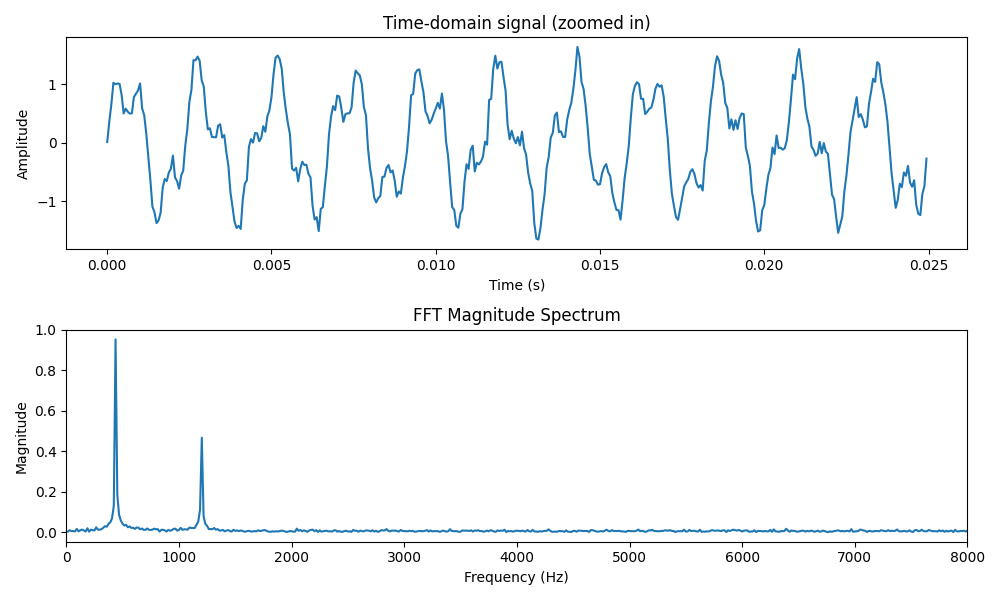

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def gen_sig_and_plot(num_samples=4096, fs=16000):
    # --- 1. Generate a test signal ---
    t = np.arange(num_samples) / fs   # sample times, based on fixed sample count

    f1, f2 = 440, 1200   # frequencies of two tones (Hz)
    signal = (
        1.0 * np.sin(2 * np.pi * f1 * t) +
        0.5 * np.sin(2 * np.pi * f2 * t) +
        0.1 * np.random.randn(num_samples)    # a bit of noise
    )

    # --- 2. Perform the FFT ---
    N = len(signal)
    fft_vals = np.fft.rfft(signal)          # real-input FFT (only positive freqs)
    fft_freqs = np.fft.rfftfreq(N, d=1/fs)  # corresponding frequency bins
    fft_mag = np.abs(fft_vals) / N * 2      # normalized magnitude

    # --- 3. Plot time-domain and frequency-domain views ---
    fig, axes = plt.subplots(2, 1, figsize=(10, 6))

    zoom = min(400, num_samples)
    axes[0].plot(t[:zoom], signal[:zoom])   # zoom into first N samples (or fewer if signal is shorter)
    axes[0].set_title("Time-domain signal (zoomed in)")
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Amplitude")

    axes[1].plot(fft_freqs, fft_mag)
    axes[1].set_title("FFT Magnitude Spectrum")
    axes[1].set_xlabel("Frequency (Hz)")
    axes[1].set_ylabel("Magnitude")
    axes[1].set_xlim(0, fs / 2)

    plt.tight_layout()
    plt.show()
    return signal, fft_vals

signal, fft_vals = gen_sig_and_plot(num_samples=1024, fs=16000) 

In [6]:
import numpy as np
from pathlib import Path

# --- Helper: format a float32 array as C source body ---
def format_array_body(data, per_line=8):
    lines = []
    for i in range(0, len(data), per_line):
        row = ", ".join(f"{v:.10f}f" for v in data[i:i+per_line])
        lines.append("    " + row + ",")
    return "\n".join(lines)

# --- Helper: write a single array as a .c/.h pair into a target directory ---
def write_c_pair(name, data, output_dir=".", dtype="float32_t"):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    c_path = output_dir / f"{name}.c"
    h_path = output_dir / f"{name}.h"
    guard = f"{name.upper()}_H"

    body = format_array_body(data)

    with open(c_path, "w") as f:
        f.write(f'#include "{h_path.name}"\n\n')
        f.write(f"const uint32_t {name.upper()}_LEN = {len(data)};\n\n")
        f.write(f"{dtype} {name}[{len(data)}] = {{\n{body}\n}};\n")

    with open(h_path, "w") as f:
        f.write(f"#ifndef {guard}\n#define {guard}\n\n")
        f.write(f'#include "arm_math.h"\n\n')
        f.write(f"extern const uint32_t {name.upper()}_LEN;\n")
        f.write(f"extern {dtype} {name}[{len(data)}];\n\n")
        f.write(f"#endif // {guard}\n")

    print(f"Wrote {c_path} and {h_path}")

# --- Repack a numpy rfft result into CMSIS arm_rfft_fast_f32 packed format ---
def pack_cmsis_rfft(fft_ref, N):
    if len(fft_ref) != N // 2 + 1:
        raise ValueError(f"fft_ref length {len(fft_ref)} does not match expected N/2+1 = {N//2+1}")

    packed = np.zeros(N, dtype=np.float32)
    packed[0] = fft_ref[0].real          # DC
    packed[1] = fft_ref[N // 2].real     # Nyquist (packed into DC's imag slot)
    for k in range(1, N // 2):
        packed[2 * k] = fft_ref[k].real
        packed[2 * k + 1] = fft_ref[k].imag
    return packed

# --- Top-level reusable export function ---
def export_rfft_test_vectors(name_prefix, signal, fft_ref, N, output_dir="."):
    """
    Writes two .c/.h pairs for use as CMSIS arm_rfft_fast_f32 unit test vectors:
      {name_prefix}_input.c/.h      - the time-domain input signal
      {name_prefix}_fft_output.c/.h - the expected CMSIS-packed FFT output

    Parameters
    ----------
    name_prefix : str
        Base name used for generated files and C symbol names.
    signal : array-like, float32
        Time-domain input signal, length N.
    fft_ref : array-like, complex
        Output of np.fft.rfft(signal), length N/2 + 1.
    N : int
        FFT length (must be a CMSIS-supported size: 32...4096, power of 2).
    output_dir : str or Path
        Directory to write the .c/.h files into. Created if it doesn't exist.
    """
    signal = np.asarray(signal, dtype=np.float32)
    if len(signal) != N:
        raise ValueError(f"signal length {len(signal)} does not match N = {N}")

    packed = pack_cmsis_rfft(fft_ref, N)

    write_c_pair(f"{name_prefix}_input", signal, output_dir=output_dir)
    write_c_pair(f"{name_prefix}_output", packed, output_dir=output_dir)


# --- Usage ---
N = len(signal)
export_rfft_test_vectors("spectrogram_signal", signal, fft_vals, N, output_dir="./test_vectors") 

Wrote test_vectors/spectrogram_signal_input.c and test_vectors/spectrogram_signal_input.h
Wrote test_vectors/spectrogram_signal_output.c and test_vectors/spectrogram_signal_output.h


## Visualize Spectrogram

Parsed 1350 values, expected 1350 (ROWS=30 x COLS=45)


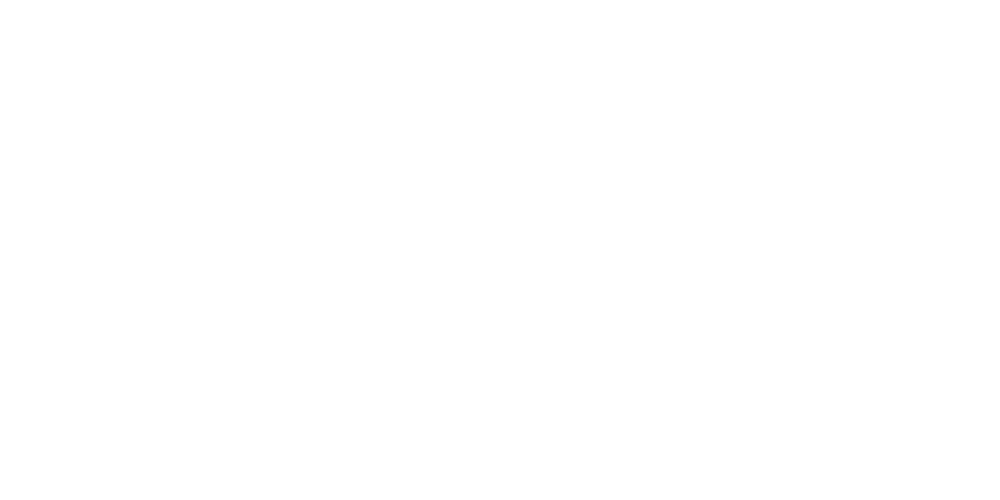

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import re

NMELS = 30
SPECTROGRAM_ROWS = NMELS
SPECTROGRAM_COLS = 45

# --- 1. Paste your raw C output here ---
raw_output = """
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
"""
# (paste your full block in place of "..." above)

# --- 2. Parse into a flat float32 array ---
def parse_c_output(raw_text):
    quoted_lines = re.findall(r'"([^"]*)"', raw_text)
    values = []
    for line in quoted_lines:
        line = line.strip()
        if not line:
            continue
        values.extend(float(v) for v in line.split())
    return np.array(values, dtype=np.float32)

flat = parse_c_output(raw_output)
expected_len = SPECTROGRAM_ROWS * SPECTROGRAM_COLS

print(f"Parsed {len(flat)} values, expected {expected_len} "
      f"(ROWS={SPECTROGRAM_ROWS} x COLS={SPECTROGRAM_COLS})")

if len(flat) != expected_len:
    raise ValueError("Length mismatch — check that the full C output was pasted in.")

# --- 3. Reshape matching the C memory layout: index = col * ROWS + row ---
# This means: fastest-varying index is row, i.e. column-major storage.
# NumPy's default reshape is row-major, so reshape as (COLS, ROWS) first,
# then transpose to get back to (ROWS, COLS) = (mel bin, time frame).
spectrogram = flat.reshape(SPECTROGRAM_COLS, SPECTROGRAM_ROWS).T

assert spectrogram.shape == (SPECTROGRAM_ROWS, SPECTROGRAM_COLS)

# --- 4. Plot as heatmap ---
plt.figure(figsize=(10, 5))
plt.imshow(spectrogram, aspect="auto", origin="lower", cmap="viridis")
plt.colorbar(label="Magnitude")
plt.xlabel("Time frame")
plt.ylabel("Mel bin")
plt.title("Mel Spectrogram (from C output)")
plt.tight_layout()
plt.show()

# # --- Optional: log-scaled version ---
# plt.figure(figsize=(10, 5))
# spectrogram_db = 10 * np.log10(np.maximum(spectrogram, 1e-8))
# plt.imshow(spectrogram_db, aspect="auto", origin="lower", cmap="viridis")
# plt.colorbar(label="Magnitude (dB)")
# plt.xlabel("Time frame")
# plt.ylabel("Mel bin")
# plt.title("Mel Spectrogram (log scale, from C output)")
# plt.tight_layout()
# plt.show()

## Write Spectrogram Output

In [18]:
import re
from pathlib import Path

def parse_raw_output(raw_output: str) -> list[float]:
    """Extract every float from the quoted lines in raw_output, as one flat list."""
    values = []
    for line in raw_output.strip().splitlines():
        line = line.strip()
        if not line.startswith('- "'):
            continue
        m = re.search(r'"([^"]*)"', line)
        if not m:
            continue
        values.extend(float(tok) for tok in m.group(1).split())
    return values


def write_c_test_vectors(
    values: list[float],
    name: str,
    out_dir: str = ".",
    dtype: str = "float32_t",
    values_per_line: int = 10,
):
    """Write a header + source file exposing values as a flat C array."""
    upper = name.upper()
    guard = f"{upper}_H"
    h_path = Path(out_dir) / f"{name}.h"
    c_path = Path(out_dir) / f"{name}.c"
    n = len(values)

    header = f"""#ifndef {guard}
#define {guard}

#include <stdint.h>
#include "arm_math_types.h"  /* for {dtype} */

#define {upper}_LEN ({n})

extern const {dtype} {name}[{upper}_LEN];

#endif /* {guard} */
"""

    lines = []
    for i in range(0, n, values_per_line):
        chunk = values[i:i + values_per_line]
        lines.append("    " + ", ".join(f"{v:.7g}f" for v in chunk) + ",")
    lines[-1] = lines[-1].rstrip(",")

    source = f"""#include "{name}.h"

const {dtype} {name}[{upper}_LEN] = {{
""" + "\n".join(lines) + "\n};\n"

    h_path.write_text(header)
    c_path.write_text(source)
    return h_path, c_path, n


if __name__ == "__main__":
    raw_output = """
 - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
  - "0.2865859 1.737588 9.214537 9.015504 1.717319 0.7261 1.103719 2.419446 1.800393 2.174744 "
  - "7.646146 7.752764 1.745823 1.743457 2.528549 1.816087 1.120949 1.891174 2.685101 2.592146 "
  - "2.186161 2.482643 2.731982 2.653965 2.970262 2.815072 3.140915 3.302467 2.800216 2.915515 "
"""  # ← paste your full raw_output here

    values = parse_raw_output(raw_output)
    print(f"Parsed {len(values)} values")

    h_path, c_path, n = write_c_test_vectors(values, name="spectrogram_output", out_dir="test_vectors")
    print(f"Wrote {h_path} and {c_path} ({n} values)")

Parsed 1350 values
Wrote test_vectors/spectrogram_output.h and test_vectors/spectrogram_output.c (1350 values)


# Mel Filter Calculations

In [8]:
import numpy as np

def hz_to_mel(f, formula="htk"):
    f = np.asarray(f, dtype=float)
    if formula == "htk":
        return 2595.0 * np.log10(1.0 + f / 700.0)
    elif formula == "slaney":
        f_min = 0.0
        f_sp = 200.0 / 3
        mel = (f - f_min) / f_sp
        min_log_hz = 1000.0
        min_log_mel = (min_log_hz - f_min) / f_sp
        logstep = np.log(6.4) / 27.0
        return np.where(f >= min_log_hz,
                         min_log_mel + np.log(np.maximum(f, 1e-10) / min_log_hz) / logstep,
                         mel)
    else:
        raise ValueError(f"Unknown formula: {formula}")

def mel_to_hz(m, formula="htk"):
    m = np.asarray(m, dtype=float)
    if formula == "htk":
        return 700.0 * (10.0 ** (m / 2595.0) - 1.0)
    elif formula == "slaney":
        f_min = 0.0
        f_sp = 200.0 / 3
        min_log_hz = 1000.0
        min_log_mel = (min_log_hz - f_min) / f_sp
        logstep = np.log(6.4) / 27.0
        return np.where(m >= min_log_mel,
                         min_log_hz * np.exp(logstep * (m - min_log_mel)),
                         f_min + f_sp * m)
    else:
        raise ValueError(f"Unknown formula: {formula}")

def mel_filterbank_bin_edges(n_mels, fft_len, samp_rate, fmin, fmax, formula="htk"):
    """Returns the n_mels+2 FFT-bin edge indices used to build the triangular filters."""
    mel_min = hz_to_mel(fmin, formula)
    mel_max = hz_to_mel(fmax, formula)
    mel_pts = np.linspace(mel_min, mel_max, n_mels + 2)
    hz_pts = mel_to_hz(mel_pts, formula)
    bin_pts = np.floor(fft_len * hz_pts / samp_rate).astype(int)
    return bin_pts

def compute_mel_filter_layout(n_mels, fft_len, samp_rate, fmin, fmax, formula="htk"):
    """
    Returns (total_coeffs, start_indices, stop_indices) for the given
    MelFilterTypeDef parameters -- mirrors what MelFilterbank_Init produces,
    without needing to call it or know the sizes ahead of time.
    """
    edges = mel_filterbank_bin_edges(n_mels, fft_len, samp_rate, fmin, fmax, formula)
    starts, stops = [], []
    total = 0
    for i in range(n_mels):
        start = int(edges[i])
        stop = int(edges[i + 2]) - 1
        width = max(stop - start + 1, 0)
        starts.append(start)
        stops.append(stop)
        total += width
    return total, starts, stops


# --- Example: matches the docstring exactly ---
total, starts, stops = compute_mel_filter_layout(
    n_mels=40, fft_len=1024, samp_rate=16000, fmin=20.0, fmax=4000.0, formula="htk"
)
print(f"pMelFilterCoefs size needed: {total}")  # -> 493, matches the docs

# --- Your actual config ---
total2, _, _ = compute_mel_filter_layout(
    n_mels=30, fft_len=512, samp_rate=16000, fmin=125.0, fmax=7500.0, formula="slaney"
)
print(f"Your config needs: {total2}")  # -> 968, matches your LUT exactly

pMelFilterCoefs size needed: 493
Your config needs: 447
